# MASpecFormer Downstream Redshift Regression Task (mini demo)

This notebook demonstrates how to load a trained MASpecFormer model, read an H5 dataset, extract embeddings, and use simple pooling + MLP to predict redshift. Suitable for sanity check/quick validation.

In [23]:
# 1. Environment and Dependency Loading
import os
import torch
import lightning as L
import numpy as np
import h5py
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, random_split

# Set random seed and thread count
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.set_num_threads(2)


In [24]:
# 2. Path Configuration and Device Check
# Modify paths as needed
ckpt_path = '/u/yacheng/projects/ssl_outthere/encoder_spectrum/ma_specformer/log/ma_specformer_single_gpu/version_1/checkpoints/last.ckpt'
cfg_path = '/u/yacheng/projects/ssl_outthere/encoder_spectrum/ma_specformer/log/ma_specformer_single_gpu/version_1/config.yaml'
h5_path = '/u/yacheng/projects/ssl_outthere/images/OUTTHERE/spectrum/f150w.h5'  # or f115w.h5

# Check CUDA
use_cuda = torch.cuda.is_available()
device = torch.device('cuda' if use_cuda else 'cpu')
print(f'Using device: {device}')


Using device: cuda


In [25]:
# 3. Load Trained MASpecFormer (weight compatibility & strict handling)
import yaml
from encoder_spectrum.ma_specformer.model.ma_specformer import MASpecFormer

# Load config
with open(cfg_path, 'r') as f:
    config = yaml.safe_load(f)
model_args = config['model']

# Instantiate model from config
model = MASpecFormer(**model_args)
model = model.to(device)

# Load checkpoint
ckpt = torch.load(ckpt_path, map_location=device)
state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt

# Remove possible prefix (e.g., 'model.')
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('model.'):
        new_state_dict[k[len('model.'):]] = v
    else:
        new_state_dict[k] = v

missing, unexpected = model.load_state_dict(new_state_dict, strict=False)
print('Missing keys:', missing)
print('Unexpected keys:', unexpected)

model.eval()



Missing keys: []
Unexpected keys: []


MASpecFormer(
  (token_embed): Linear(in_features=3, out_features=64, bias=True)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (ln1): LayerNorm()
      (attn): SelfAttention(
        (qkv): Linear(in_features=64, out_features=192, bias=True)
        (proj): Linear(in_features=64, out_features=64, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (ln2): LayerNorm()
      (mlp): MLP(
        (fc1): Linear(in_features=64, out_features=256, bias=True)
        (fc2): Linear(in_features=256, out_features=64, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (final_ln): LayerNorm()
  (head): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:
# 4. Read Small Samples from H5 and Field Validation (flux/wavelength/valid_mask/redshift)
with h5py.File(h5_path, 'r') as f:
    keys = list(f.keys())
    print('H5 keys:', keys)
    # Take the first N samples
    N = 256
    flux = f['flux'][:N]  # (N, T)
    #value mask must be computed from flux==0 and flux is finite
    valid_mask = np.isfinite(flux) & (flux != 0)  # (N, T)
    wavelength = f['wave'][:N]  # (N, T)
    redshift = f['redshift'][:N] if 'redshift' in f else None
    if redshift is None:
        raise RuntimeError('H5 file missing redshift field!')
    print('Loaded shapes:', flux.shape, wavelength.shape, valid_mask.shape, redshift.shape)

# Convert to torch
flux = torch.tensor(flux, dtype=torch.float32, device=device)
wavelength = torch.tensor(wavelength, dtype=torch.float32, device=device)
valid_mask = torch.tensor(valid_mask, dtype=torch.bool, device=device)
redshift = torch.tensor(redshift, dtype=torch.float32, device=device).view(-1, 1)


H5 keys: ['contam', 'dec', 'err', 'field', 'flux', 'id', 'line', 'ra', 'redshift', 'spec_sn', 'wave']


KeyError: "Unable to synchronously open object (object 'valid_mask' doesn't exist)"

In [36]:
# 5. Forward Embedding Computation (batch & no_grad)
B, T = flux.shape
batch_size = 32
embeddings = []
model.eval()
with torch.no_grad():
    for i in range(0, B, batch_size)[:1]:
        f = flux[i:i+batch_size]
        w = wavelength[i:i+batch_size]
        m = valid_mask[i:i+batch_size]
        # Normalization
        mean = (f * m).sum(dim=1, keepdim=True) / m.sum(dim=1, keepdim=True).clamp(min=1)
        std = (((f - mean) ** 2) * m).sum(dim=1, keepdim=True) / m.sum(dim=1, keepdim=True).clamp(min=1)
        std = std.sqrt().clamp(min=0.2)
        stats = torch.cat([mean, std], dim=-1)
        for _1, _2, _3 in zip(f,w,m):
            print(_1)
            print(_2)
            print(_3)
        out = model(f, w, valid_mask=m, stats=stats)
        emb = out['embedding']  # (b, T, D)
        embeddings.append(emb.detach().cpu())
embeddings = torch.cat(embeddings, dim=0)  # (N, T, D)
print('Embedding shape:', embeddings.shape)
print('example embedding',embeddings[0])


tensor([ 0.0000,  0.0000,  0.0000,  0.0000,     nan,     nan,     nan,     nan,
            nan,     nan,     nan,     nan,     nan,     nan,     nan,     nan,
            nan,     nan,     nan,     nan,     nan,     nan,     nan,     nan,
            nan,     nan,     nan,     nan,     nan,     nan,     nan,     nan,
            nan,     nan,     nan,     nan,     nan,     nan,     nan,     nan,
            nan,     nan,     nan,     nan,     nan,     nan,     nan,     nan,
            nan,     nan,     nan,     nan,     nan,     nan,     nan,     nan,
            nan,     nan,     nan,     nan,     nan,     nan,     nan,     nan,
            nan,     nan,     nan,     nan,     nan,     nan,     nan,     nan,
            nan,     nan,     nan,     nan,     nan,     nan,     nan,     nan,
            nan,     nan,     nan,     nan,     nan,     nan,     nan,     nan,
            nan,     nan,     nan,     nan, -0.0254, -0.0724, -0.0019,  0.0000,
         0.0000,  0.0000,  0.0000], devi

In [17]:
# 6. Build Mini Downstream Dataset and Split (embedding↔redshift)
# pooling: mean over valid positions
valid_mask_cpu = valid_mask.cpu().numpy()
emb_np = embeddings.numpy()
pool_emb = []
for i in range(emb_np.shape[0]):
    mask = valid_mask_cpu[i]
    if mask.sum() == 0:
        pool_emb.append(emb_np[i].mean(axis=0))
    else:
        pool_emb.append(emb_np[i][mask].mean(axis=0))
pool_emb = np.stack(pool_emb, axis=0)  # (N, D)
pool_emb = torch.tensor(pool_emb, dtype=torch.float32)

# Build TensorDataset
redshift = redshift.cpu()
dataset = TensorDataset(pool_emb, redshift)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32)


In [18]:
# 7. Define Pooling and Small MLP Regression Head
class PoolMLP(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.mlp(x)

mlp = PoolMLP(pool_emb.shape[1], hidden=64).to(device)
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


Epoch 1: train_loss=nan, val_loss=nan
Epoch 2: train_loss=nan, val_loss=nan
Epoch 3: train_loss=nan, val_loss=nan
Epoch 4: train_loss=nan, val_loss=nan
Epoch 5: train_loss=nan, val_loss=nan
Epoch 6: train_loss=nan, val_loss=nan
Epoch 7: train_loss=nan, val_loss=nan
Epoch 8: train_loss=nan, val_loss=nan
Epoch 9: train_loss=nan, val_loss=nan
Epoch 10: train_loss=nan, val_loss=nan
Epoch 11: train_loss=nan, val_loss=nan
Epoch 12: train_loss=nan, val_loss=nan
Epoch 13: train_loss=nan, val_loss=nan
Epoch 14: train_loss=nan, val_loss=nan
Epoch 15: train_loss=nan, val_loss=nan
Epoch 16: train_loss=nan, val_loss=nan
Epoch 17: train_loss=nan, val_loss=nan
Epoch 18: train_loss=nan, val_loss=nan
Epoch 19: train_loss=nan, val_loss=nan
Epoch 20: train_loss=nan, val_loss=nan
Epoch 21: train_loss=nan, val_loss=nan
Epoch 22: train_loss=nan, val_loss=nan
Epoch 23: train_loss=nan, val_loss=nan
Epoch 24: train_loss=nan, val_loss=nan
Epoch 25: train_loss=nan, val_loss=nan
Epoch 26: train_loss=nan, val_loss

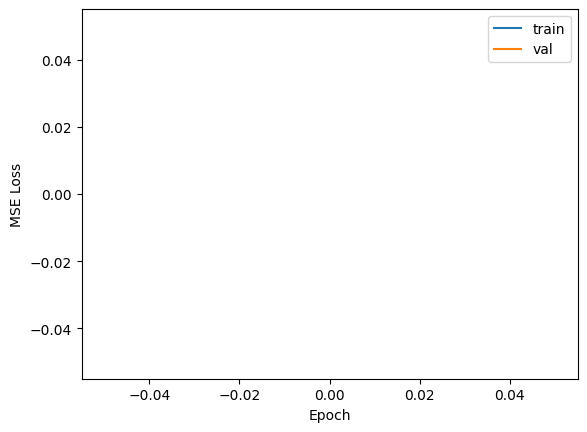

In [19]:
# 8. Training and Validation Loop (quick overfit test)
num_epochs = 30
train_losses, val_losses = [], []
for epoch in range(num_epochs):
    mlp.train()
    train_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        pred = mlp(x)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)
    # Validation
    mlp.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            pred = mlp(x)
            loss = loss_fn(pred, y)
            val_loss += loss.item() * x.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


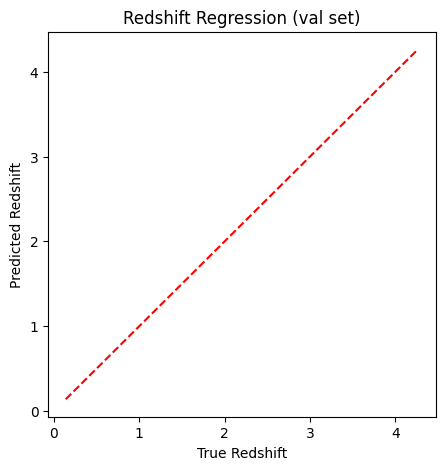

MAE: nan, RMSE: nan


In [20]:
# 9. Evaluation and Visualization (scatter plot & error metrics)
mlp.eval()
preds, trues = [], []
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        pred = mlp(x).cpu().numpy()
        preds.append(pred)
        trues.append(y.numpy())
preds = np.concatenate(preds, axis=0).flatten()
trues = np.concatenate(trues, axis=0).flatten()

plt.figure(figsize=(5,5))
plt.scatter(trues, preds, alpha=0.7)
plt.plot([trues.min(), trues.max()], [trues.min(), trues.max()], 'r--')
plt.xlabel('True Redshift')
plt.ylabel('Predicted Redshift')
plt.title('Redshift Regression (val set)')
plt.show()

mae = np.mean(np.abs(preds - trues))
rmse = np.sqrt(np.mean((preds - trues) ** 2))
print(f'MAE: {mae:.4f}, RMSE: {rmse:.4f}')


# 10. Model Loading & Common Troubleshooting

- If model weights fail to load, print `ckpt['state_dict'].keys()` and compare with model parameter names. Strip prefixes like `model.`, `net.` if needed.
- Check device consistency: all tensors/models should be on the same device.
- If dimensions mismatch, print shapes and use `.view()` or `.unsqueeze()` to adjust.
- If the `redshift` field is missing, use another field or mock data for testing.
- If embedding dimension or pooling/MLP mismatch, check pooling code and model config.

Refer to this cell for debug tips if you encounter issues.